In [12]:
from __future__ import annotations
from typing import Iterable, List, Sequence, Tuple, Optional
import prim
from prim import plot_prim_graph
import matplotlib.pyplot as plt
import numpy as np
import math

In [13]:
Point = Tuple[float, float]

In [14]:
def compute_complete_edges(points: Sequence[Point]) -> List[Tuple[Point, Point]]:
    """
    Génère toutes les arêtes du graphe complet pour une liste de points.

    Parameters
    ----------
    points : Sequence[Point]
        Liste/tuple de points (x, y).

    Returns
    -------
    List[Tuple[Point, Point]]
        Liste des paires (p_i, p_j) avec i < j.
    """
    n = len(points)
    edges: List[Tuple[Point, Point]] = []
    for i in range(n):
        for j in range(i + 1, n):
            edges.append((points[i], points[j]))
    return edges


def draw_complete_graph(points: Sequence[Point],
                        *,
                        annotate: bool = False,
                        labels: Optional[Iterable[str]] = None,
                        point_size: int = 40,
                        line_width: float = 1.0,
                        line_alpha: float = 1,
                        figsize: Tuple[int, int] = (6, 6),
                        equal_axis: bool = True,
                        axis_off: bool = False,
                        save_path: Optional[str] = None,
                        show: bool = True) -> plt.Axes:
    """
    Trace un graphe complet reliant tous les points fournis.

    Parameters
    ----------
    points : Sequence[Point]
        Liste/tuple de coordonnées (x, y).
    annotate : bool, optional
        Si True, ajoute une étiquette à chaque point (labels si fournis,
        sinon l'indice). Default: False.
    labels : Optional[Iterable[str]], optional
        Étiquettes à afficher pour chaque point (même longueur que `points`).
    point_size : int, optional
        Taille des marqueurs. Default: 40.
    line_width : float, optional
        Épaisseur des arêtes. Default: 1.0.
    line_alpha : float, optional
        Transparence des arêtes (utile quand il y en a beaucoup). Default: 1.
    figsize : Tuple[int, int], optional
        Taille de la figure en pouces. Default: (6, 6).
    equal_axis : bool, optional
        Si True, impose le même ratio d’échelle pour x et y. Default: True.
    axis_off : bool, optional
        Si True, cache les axes. Default: False.
    save_path : Optional[str], optional
        Chemin de sauvegarde (PNG, PDF, etc.). Si None, ne sauvegarde pas.
    show : bool, optional
        Si True, affiche la figure. Default: True.

    Returns
    -------
    plt.Axes
        Axes matplotlib contenant le tracé.

    Notes
    -----
    - Complexité en O(n^2) arêtes : attention pour n élevé.
    """
    if len(points) == 0:
        raise ValueError("La liste de points est vide.")
    if labels is not None:
        labels = list(labels)
        if len(labels) != len(points):
            raise ValueError("`labels` doit avoir la même longueur que `points`.")

    fig, ax = plt.subplots(figsize=figsize)

    # Tracer toutes les arêtes du graphe complet
    for (x1, y1), (x2, y2) in compute_complete_edges(points):
        ax.plot([x1, x2], [y1, y2], linewidth=line_width, alpha=line_alpha)
        dist = math.hypot(x2 - x1, y2 - y1) #TODO: Ajouter des poids en fonction du mode de livraison
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.annotate(f"{dist:.2f}", (mid_x, mid_y), ha="center", va="center", fontsize=8, color="blue")

    # Tracer les points
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    ax.scatter(xs, ys, s=point_size)

    # Options d’axes
    if equal_axis:
        ax.set_aspect('equal', adjustable='box')
    if axis_off:
        ax.axis('off')

    # Annotations
    if annotate:
        if labels is None:
            for i, (x, y) in enumerate(points):
                ax.annotate(str(i), (x, y), xytext=(5, 5), textcoords='offset points')
        else:
            for lab, (x, y) in zip(labels, points):
                ax.annotate(str(lab), (x, y), xytext=(5, 5), textcoords='offset points')

    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
    if show:
        plt.show()

    return ax

In [15]:
def compute_adjacence_matrix(points: Sequence[Point]) -> List[List[float]]:
    """
    Construit la matrice d'adjacence pondérée d'un graphe complet
    basé sur une liste de points.

    Parameters
    ----------
    points : Sequence[Point]
        Liste de coordonnées (x, y).

    Returns
    -------
    List[List[float]]
        Matrice d'adjacence (n x n) où chaque élément [i][j] représente
        le poids (distance euclidienne) entre le point i et le point j.
        La diagonale est nulle.
    """
    n = len(points)
    matrix = [[0.0 for _ in range(n)] for _ in range(n)]

    for i in range(n):
        for j in range(i + 1, n):
            dist = round(math.hypot(points[j][0] - points[i][0],points[j][1] - points[i][1]),2)
            matrix[i][j] = dist
            matrix[j][i] = dist
    return matrix

def show_adjacence_matrix(m : List[List[float]]) :
    name_columns = " "
    for i in range(len(m)):
        name_columns += "  " + str(i)

    for i in range(len(m)):
        print(str(i) + " " + str(m[i]))


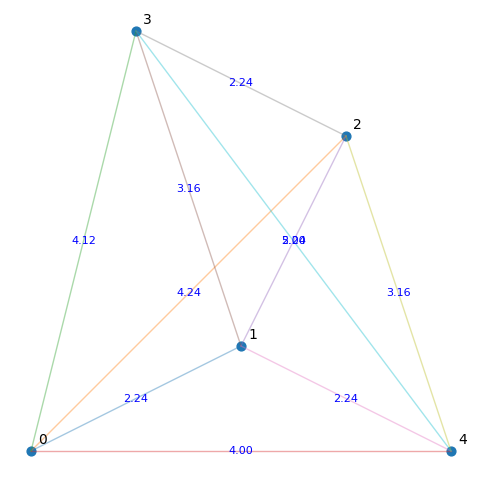

0 [0.0, 2.24, 4.24, 4.12, 4.0]
1 [2.24, 0.0, 2.24, 3.16, 2.24]
2 [4.24, 2.24, 0.0, 2.24, 3.16]
3 [4.12, 3.16, 2.24, 0.0, 5.0]
4 [4.0, 2.24, 3.16, 5.0, 0.0]


In [16]:
if __name__ == "__main__":
    # Exemple d'utilisation
    points = [(0, 0), (2, 1), (3, 3), (1, 4), (4, 0)]

    # Tracer le graphe complet avec annotations
    draw_complete_graph(points, annotate=True, axis_off=True, line_alpha=0.4)
    m = compute_adjacence_matrix(points)
    show_adjacence_matrix(m)

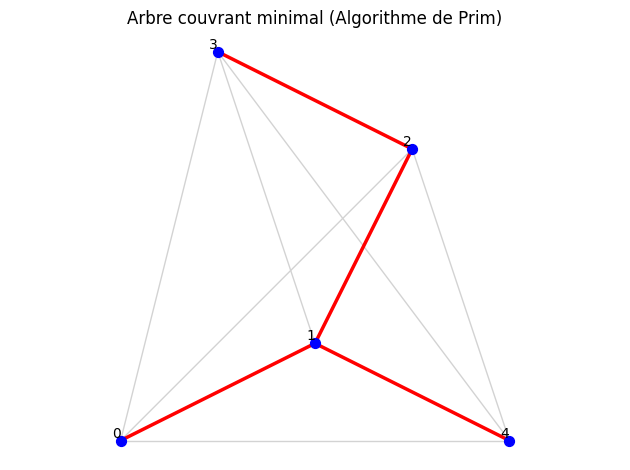

In [17]:
edges, total, parent, key = prim.prim_mst_complete(m)
plot_prim_graph(points, edges)

# Affichage des Complexités avec un graphique temporelle

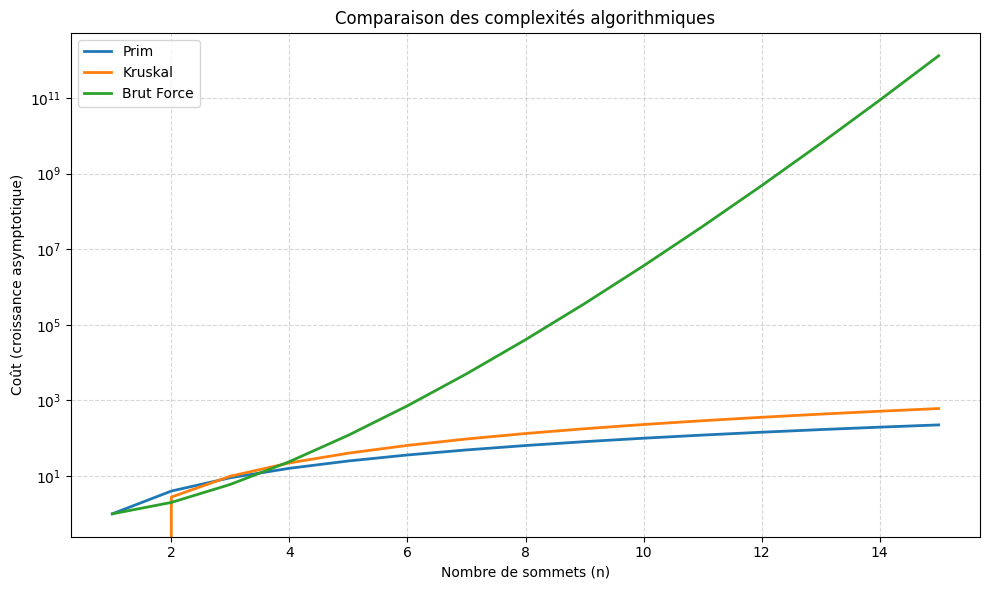

In [27]:
def plot_complexity_comparison(complexities: list, labels: list, n_max: int = 15):
    """
    Affiche la croissance des complexités asymptotiques données en fonction de n.

    Paramètres
    ----------
    complexities : list
        Liste de fonctions lambda prenant n en entrée (ex: [lambda n: n**2, lambda n: n**2*math.log(n)]).
    labels : list
        Noms correspondants aux complexités (ex: ["O(n²)", "O(n² log n)", "O(n!)"]).
    n_max : int
        Taille maximale de n pour l'affichage (par défaut : 15, car n! devient vite énorme).

    Exemple
    -------
    >>> plot_complexity_comparison(
    ...     [lambda n: n**2, lambda n: n**2*math.log(n), lambda n: math.factorial(n)],
    ...     ["O(n²)", "O(n² log n)", "O(n!)"],
    ...     n_max=10
    ... )
    """
    n_values = np.arange(1, n_max + 1)
    plt.figure(figsize=(10, 6))

    for func, label in zip(complexities, labels):
        y = [func(n) for n in n_values]
        plt.plot(n_values, y, label=label, linewidth=2)

    plt.yscale('log')  # Échelle logarithmique pour visualiser les écarts
    plt.xlabel("Nombre de sommets (n)")
    plt.ylabel("Coût (croissance asymptotique)")
    plt.title("Comparaison des complexités algorithmiques")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_complexity_comparison(
        [
            lambda n: n**2,
            lambda n: n**2 * math.log(n),
            lambda n: math.factorial(n)
        ],
        ["Prim", "Kruskal", "Brut Force"],
        n_max=15
    )